
**Makine Öğrenmesi Ara Ödev**

Bu çalışmanın amacı, müşteri ayrılma tahmini problemi üzerinden
temel bir makine öğrenmesi sınıflandırma akışını uygulamaktır.

Çalışmada veri inceleme, veri ön işleme, öznitelik üretme,
train-validation-test ayrımı, model eğitimi ve model değerlendirme
adımları uygulanacaktır.

Kullanılan kütüphaneler:
- pandas
- numpy
- scikit-learn
- matplotlib
- seaborn

Çalıştırma:
1. Gerekli kütüphaneleri yükleyin.
2. Müşteri churn veri setini Colab ortamına yükleyin.
3. Bu Python dosyasındaki hücreleri sırasıyla çalıştırın.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("musteri_churn_120.csv")

In [ ]:
# Veri setinin ilk 5 gözlemi incelenmektedir.

df.head()

,yas,maas,sehir,egitim,abonelik_suresi,destek_talebi,aylik_ucret,churn
0,58.0,81090.0,Bursa,On Lisans,12.0,3.0,562.0,0
1,48.0,78640.0,Izmir,Lisans,53.0,5.0,692.0,0
2,34.0,25206.0,Izmir,On Lisans,1.0,2.0,577.0,1
3,27.0,46518.0,Ankara,On Lisans,58.0,4.0,303.0,0
4,40.0,47361.0,Antalya,Lisans,58.0,3.0,488.0,0


In [ ]:
# Veri setinin gözlem ve değişken sayısı kontrol edilmektedir.

df.shape

(120, 8)

In [ ]:
# Veri setinde yer alan değişkenlerin isimleri incelenmektedir.

df.columns.tolist()

['yas',
 'maas',
 'sehir',
 'egitim',
 'abonelik_suresi',
 'destek_talebi',
 'aylik_ucret',
 'churn']

In [ ]:
# Değişkenlerin veri tipleri kontrol edilmektedir.

df.dtypes

,0
yas,float64
maas,float64
sehir,object
egitim,object
abonelik_suresi,float64
destek_talebi,float64
aylik_ucret,float64
churn,int64


In [ ]:
# Hedef değişkenin sınıf dağılımı incelenmektedir.

df["churn"].value_counts()

,count
churn,
0,83
1,37


In [ ]:
# Hedef değişkenin sınıf oranları incelenmektedir.

df["churn"].value_counts(normalize=True) * 100

,proportion
churn,
0,69.166667
1,30.833333



> ***Hedef değişken incelendiğinde müşterilerin %69,17'sinin ayrılmadığı, %30,83'ünün ise ayrıldığı görülmektedir. Sınıflar arasında belirli bir dengesizlik bulunmakla birlikte, her iki sınıfta da yeterli sayıda gözlem bulunmaktadır.***

In [ ]:
# Değişkenlerde bulunan eksik değerlerin sayısı kontrol edilmektedir.

df.isnull().sum()

,0
yas,2
maas,3
sehir,0
egitim,2
abonelik_suresi,2
destek_talebi,1
aylik_ucret,0
churn,0


In [ ]:
# Değişkenlerdeki eksik değer oranları hesaplanmaktadır.

(df.isnull().sum() / len(df)) * 100

,0
yas,1.666667
maas,2.500000
sehir,0.000000
egitim,1.666667
abonelik_suresi,1.666667
destek_talebi,0.833333
aylik_ucret,0.000000
churn,0.000000



> ***Veri setinde yas, maas, egitim, abonelik_suresi ve destek_talebi değişkenlerinde eksik değerler bulunmaktadır. Eksik değer oranlarının %0,83 ile %2,50 arasında değiştiği görülmektedir. Eksik değer oranları düşük olduğu için gözlemleri tamamen silmek yerine uygun değerlerle doldurma yöntemi tercih edilecektir. churn değişkeninde eksik değer bulunmadığından hedef değişkende herhangi bir veri kaybı oluşmamaktadır.***

In [ ]:
# Sayısal değişkenler belirlenmektedir.

sayisal_degiskenler = [
    "yas",
    "maas",
    "abonelik_suresi",
    "destek_talebi",
    "aylik_ucret"
]

In [ ]:
# Kategorik değişkenler belirlenmektedir.

kategorik_degiskenler = [
    "sehir",
    "egitim"
]

In [ ]:
# Sayısal değişkenlerdeki eksik değerler medyan ile doldurulmaktadır.

for degisken in sayisal_degiskenler:
    df[degisken] = df[degisken].fillna(df[degisken].median())

In [ ]:
# Kategorik değişkenlerde eksikler en sık değerle doldurulur.

for degisken in kategorik_degiskenler:
    df[degisken] = df[degisken].fillna(df[degisken].mode()[0])

In [ ]:
# Eksik değerlerin doldurulma durumu kontrol edilmektedir.

df.isnull().sum()

,0
yas,0
maas,0
sehir,0
egitim,0
abonelik_suresi,0
destek_talebi,0
aylik_ucret,0
churn,0


In [ ]:
# Kategorik değişkenlerde bulunan benzersiz kategoriler incelenmektedir.

print("Şehir kategorileri:")
print(df["sehir"].unique())

print("\nEğitim kategorileri:")
print(df["egitim"].unique())

Şehir kategorileri:
['Bursa' 'Izmir' 'Ankara' 'Antalya' 'Istanbul']

Eğitim kategorileri:
['On Lisans' 'Lisans' 'Yuksek Lisans' 'Lise']


In [ ]:
# Kategorik ve sayısal değişkenler belirlenmektedir.

kategorik_degiskenler = ["sehir", "egitim"]

sayisal_degiskenler = [
    "yas",
    "maas",
    "abonelik_suresi",
    "destek_talebi",
    "aylik_ucret"
]

In [ ]:
# Kategorik değişkenlere One-Hot Encoding uygulanmaktadır.

on_isleme = ColumnTransformer(
    transformers=[
        ("kategorik", OneHotEncoder(handle_unknown="ignore"), kategorik_degiskenler)
    ],
    remainder="passthrough"
)

In [ ]:
# Hedef değişken model girdilerinden ayrılmaktadır.

X = df.drop("churn", axis=1)
y = df["churn"]

# One-Hot Encoding uygulanmaktadır.
X_encoded = on_isleme.fit_transform(X)

print("Dönüştürme öncesi boyut:", X.shape)
print("Dönüştürme sonrası boyut:", X_encoded.shape)

Dönüştürme öncesi boyut: (120, 7)
Dönüştürme sonrası boyut: (120, 14)


In [ ]:
# Sayısal değişkenlere StandardScaler, kategorik değişkenlere One-Hot Encoding uygulanmaktadır.

on_isleme = ColumnTransformer(
    transformers=[
        (
            "sayisal",
            StandardScaler(),
            sayisal_degiskenler
        ),
        (
            "kategorik",
            OneHotEncoder(handle_unknown="ignore"),
            kategorik_degiskenler
        )
    ]
)

In [ ]:
# Veri setine encoding ve ölçekleme işlemleri birlikte uygulanmaktadır.

X_encoded_scaled = on_isleme.fit_transform(X)

print("İşlem sonrası veri boyutu:", X_encoded_scaled.shape)

İşlem sonrası veri boyutu: (120, 14)


In [ ]:
# Müşterinin daha önce destek talebinde bulunup bulunmadığını gösteren yeni bir öznitelik oluşturulmaktadır.

df["destek_talebi_var_mi"] = (df["destek_talebi"] > 0).astype(int)

In [ ]:
# Oluşturulan özniteliğin ilk gözlemleri incelenmektedir.

df[["destek_talebi", "destek_talebi_var_mi"]].head(10)

,destek_talebi,destek_talebi_var_mi
0,3.0,1
1,5.0,1
2,2.0,1
3,4.0,1
4,3.0,1
5,3.0,1
6,2.0,1
7,5.0,1
8,2.0,1
9,3.0,1


In [ ]:
# Oluşturulan özniteliğin sınıf dağılımı incelenmektedir.

df["destek_talebi_var_mi"].value_counts()

,count
destek_talebi_var_mi,
1,112
0,8


In [ ]:
# Hedef değişken ve bağımsız değişkenler ayrılmaktadır.

X = df.drop("churn", axis=1)
y = df["churn"]

In [ ]:
# Veri seti train ve geçici veri kümelerine ayrılmaktadır.

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

In [ ]:
# Geçici veri kümesi validation ve test kümelerine ayrılmaktadır.

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
# Oluşturulan veri kümelerinin boyutları kontrol edilmektedir.

print("Train seti:", X_train.shape)
print("Validation seti:", X_val.shape)
print("Test seti:", X_test.shape)

Train seti: (72, 8)
Validation seti: (24, 8)
Test seti: (24, 8)


In [ ]:
# Train, validation ve test kümelerindeki hedef değişken dağılımları incelenmektedir.

print("Train seti churn dağılımı:")
print(y_train.value_counts())
print()

print("Validation seti churn dağılımı:")
print(y_val.value_counts())
print()

print("Test seti churn dağılımı:")
print(y_test.value_counts())

Train seti churn dağılımı:
churn
0    50
1    22
Name: count, dtype: int64

Validation seti churn dağılımı:
churn
0    16
1     8
Name: count, dtype: int64

Test seti churn dağılımı:
churn
0    17
1     7
Name: count, dtype: int64


In [ ]:
# Veri kümelerindeki churn oranları karşılaştırılmaktadır.

print("Train seti churn oranları:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print()

print("Validation seti churn oranları:")
print((y_val.value_counts(normalize=True) * 100).round(2))
print()

print("Test seti churn oranları:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Train seti churn oranları:
churn
0    69.44
1    30.56
Name: proportion, dtype: float64

Validation seti churn oranları:
churn
0    66.67
1    33.33
Name: proportion, dtype: float64

Test seti churn oranları:
churn
0    70.83
1    29.17
Name: proportion, dtype: float64



> ***stratify kullanılarak gerçekleştirilen veri bölme işlemi sonucunda train, validation ve test kümelerindeki hedef değişken dağılımlarının birbirine yakın olduğu görülmektedir. Böylece veri kümelerinde sınıf dağılımının büyük ölçüde korunması sağlanmıştır.***

In [ ]:
# Sayısal ve kategorik değişkenler yeniden belirlenmektedir.

sayisal_degiskenler = [
    "yas",
    "maas",
    "abonelik_suresi",
    "destek_talebi",
    "aylik_ucret",
    "destek_talebi_var_mi"
]

kategorik_degiskenler = [
    "sehir",
    "egitim"
]

In [ ]:
# Sayısal değişkenler ölçeklenmekte, kategorik değişkenler One-Hot Encoding yöntemiyle sayısal forma dönüştürülmektedir.

on_isleme_pipeline = ColumnTransformer(
    transformers=[
        (
            "sayisal",
            StandardScaler(),
            sayisal_degiskenler
        ),
        (
            "kategorik",
            OneHotEncoder(handle_unknown="ignore"),
            kategorik_degiskenler
        )
    ]
)

In [ ]:
# Logistic Regression modeli için preprocessing ve model adımları birleştirilmektedir.

logistic_model = Pipeline(
    steps=[
        ("on_isleme", on_isleme_pipeline),
        ("model", LogisticRegression(random_state=42, max_iter=1000))
    ]
)

In [ ]:
# KNN modeli için preprocessing ve model adımları birleştirilmektedir.

knn_model = Pipeline(
    steps=[
        ("on_isleme", on_isleme_pipeline),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

In [ ]:
# Logistic Regression modeli train verisi kullanılarak eğitilmektedir.

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('on_isleme',
                 ColumnTransformer(transformers=[('sayisal', StandardScaler(),
                                                  ['yas', 'maas',
                                                   'abonelik_suresi',
                                                   'destek_talebi',
                                                   'aylik_ucret',
                                                   'destek_talebi_var_mi']),
                                                 ('kategorik',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sehir', 'egitim'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
# KNN modeli train verisi kullanılarak eğitilmektedir.

knn_model.fit(X_train, y_train)

Pipeline(steps=[('on_isleme',
                 ColumnTransformer(transformers=[('sayisal', StandardScaler(),
                                                  ['yas', 'maas',
                                                   'abonelik_suresi',
                                                   'destek_talebi',
                                                   'aylik_ucret',
                                                   'destek_talebi_var_mi']),
                                                 ('kategorik',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sehir', 'egitim'])])),
                ('model', KNeighborsClassifier())])

In [ ]:
# Logistic Regression modeli validation verisi üzerinde tahmin yapmaktadır.

y_val_pred_logistic = logistic_model.predict(X_val)

In [ ]:
# KNN modeli validation verisi üzerinde tahmin yapmaktadır.

y_val_pred_knn = knn_model.predict(X_val)

In [ ]:
# Logistic Regression modelinin validation performansı hesaplanmaktadır.

logistic_accuracy = accuracy_score(y_val, y_val_pred_logistic)
logistic_precision = precision_score(y_val, y_val_pred_logistic)
logistic_recall = recall_score(y_val, y_val_pred_logistic)
logistic_f1 = f1_score(y_val, y_val_pred_logistic)

print("Logistic Regression - Validation Sonuçları")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-score : {logistic_f1:.4f}")

Logistic Regression - Validation Sonuçları
Accuracy : 0.5000
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


In [ ]:
# KNN modelinin validation performansı hesaplanmaktadır.

knn_accuracy = accuracy_score(y_val, y_val_pred_knn)
knn_precision = precision_score(y_val, y_val_pred_knn)
knn_recall = recall_score(y_val, y_val_pred_knn)
knn_f1 = f1_score(y_val, y_val_pred_knn)

print("KNN - Validation Sonuçları")
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1-score : {knn_f1:.4f}")

KNN - Validation Sonuçları
Accuracy : 0.5000
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


In [ ]:
# Validation tahminlerinin sınıf dağılımı kontrol edilmektedir.

print("Gerçek validation değerleri:")
print(y_val.value_counts())

print("\nLogistic Regression tahminleri:")
print(pd.Series(y_val_pred_logistic).value_counts())

print("\nKNN tahminleri:")
print(pd.Series(y_val_pred_knn).value_counts())

Gerçek validation değerleri:
churn
0    16
1     8
Name: count, dtype: int64

Logistic Regression tahminleri:
0    20
1     4
Name: count, dtype: int64

KNN tahminleri:
0    20
1     4
Name: count, dtype: int64


In [ ]:
# Modellerin validation confusion matrix değerleri incelenmektedir.

print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_logistic))

print("\nKNN Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_knn))

Logistic Regression Confusion Matrix:
[[12  4]
 [ 8  0]]

KNN Confusion Matrix:
[[12  4]
 [ 8  0]]


In [ ]:
print("y_val toplam gözlem:", len(y_val))
print("y_val dağılımı:")
print(y_val.value_counts())

y_val toplam gözlem: 24
y_val dağılımı:
churn
0    16
1     8
Name: count, dtype: int64


In [ ]:
# Validation sonuçları karşılaştırılmaktadır.

validation_sonuclari = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [logistic_accuracy, knn_accuracy],
    "Precision": [logistic_precision, knn_precision],
    "Recall": [logistic_recall, knn_recall],
    "F1-score": [logistic_f1, knn_f1]
})

validation_sonuclari

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.5,0.0,0.0,0.0
1,KNN,0.5,0.0,0.0,0.0


In [ ]:
# Seçilen Logistic Regression modeli test verisi üzerinde tahmin yapmaktadır.

y_test_pred = logistic_model.predict(X_test)

In [ ]:
# Test tahminlerinin sınıf dağılımı incelenmektedir.

print("Gerçek test değerleri:")
print(y_test.value_counts())

print("\nModel tahminleri:")
print(pd.Series(y_test_pred).value_counts())

Gerçek test değerleri:
churn
0    17
1     7
Name: count, dtype: int64

Model tahminleri:
0    19
1     5
Name: count, dtype: int64


In [ ]:
# Seçilen modelin test setindeki confusion matrix değeri hesaplanmaktadır.

test_cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(test_cm)

Confusion Matrix:
[[15  2]
 [ 4  3]]


In [ ]:
# Test seti için sınıflandırma metrikleri hesaplanmaktadır.

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("\nTest Sonuçları")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")


Test Sonuçları
Accuracy : 0.7500
Precision: 0.6000
Recall   : 0.4286
F1-score : 0.5000


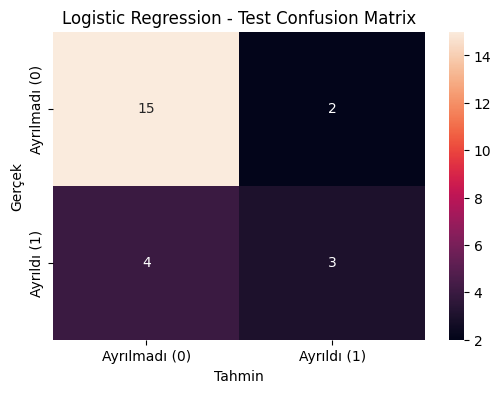

In [ ]:
# Confusion matrix görselleştirilmektedir.

plt.figure(figsize=(6, 4))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    xticklabels=["Ayrılmadı (0)", "Ayrıldı (1)"],
    yticklabels=["Ayrılmadı (0)", "Ayrıldı (1)"]
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Logistic Regression - Test Confusion Matrix")
plt.show()

In [ ]:
# Validation sonuçlarına göre modeller karşılaştırılmaktadır.

if logistic_f1 > knn_f1:
    secilen_model = "Logistic Regression"
    yorum = (
        "Validation sonuçlarına göre Logistic Regression modeli daha iyi "
        "performans göstermiştir. Modelin F1-score değeri KNN modelinden "
        "daha yüksek olduğu için Logistic Regression seçilmiştir."
    )

elif knn_f1 > logistic_f1:
    secilen_model = "KNN"
    yorum = (
        "Validation sonuçlarına göre KNN modeli daha iyi performans "
        "göstermiştir. Modelin F1-score değeri Logistic Regression "
        "modelinden daha yüksek olduğu için KNN seçilmiştir."
    )

else:
    secilen_model = "Logistic Regression"
    yorum = (
        "Validation sonuçlarında Logistic Regression ve KNN modelleri "
        "aynı F1-score değerini vermiştir. Performans açısından eşitlik "
        "olduğu için daha basit ve yorumlanabilir olması nedeniyle "
        "Logistic Regression modeli seçilmiştir."
    )

print("Seçilen Model:", secilen_model)
print("Sonuç Yorumu:")
print(yorum)

Seçilen Model: Logistic Regression
Sonuç Yorumu:
Validation sonuçlarında Logistic Regression ve KNN modelleri aynı F1-score değerini vermiştir. Performans açısından eşitlik olduğu için daha basit ve yorumlanabilir olması nedeniyle Logistic Regression modeli seçilmiştir.


Veri seti başarıyla yüklenmiştir.

--- Veri Setinin İlk 5 Gözlemi ---
    yas     maas    sehir     egitim  abonelik_suresi  destek_talebi  \
0  58.0  81090.0    Bursa  On Lisans             12.0            3.0   
1  48.0  78640.0    Izmir     Lisans             53.0            5.0   
2  34.0  25206.0    Izmir  On Lisans              1.0            2.0   
3  27.0  46518.0   Ankara  On Lisans             58.0            4.0   
4  40.0  47361.0  Antalya     Lisans             58.0            3.0   

   aylik_ucret  churn  
0        562.0      0  
1        692.0      0  
2        577.0      1  
3        303.0      0  
4        488.0      0  

--- Veri Setinin Boyutu ---
(120, 8)

--- Değişkenler ---
['yas', 'maas', 'sehir', 'egitim', 'abonelik_suresi', 'destek_talebi', 'aylik_ucret', 'churn']

--- Veri Tipleri ---
yas                float64
maas               float64
sehir               object
egitim              object
abonelik_suresi    float64
destek_talebi      float64
aylik_ucret    

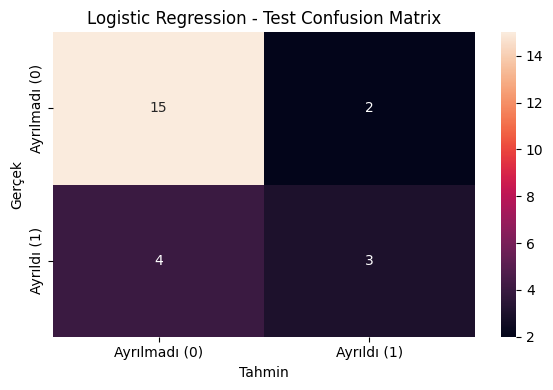


--- Sonuç Yorumu ---
Validation sonuçlarında Logistic Regression ve KNN modelleri aynı F1-score değerini vermiştir. Performans açısından eşitlik olduğu için daha basit ve yorumlanabilir olması nedeniyle Logistic Regression modeli seçilmiştir.


In [ ]:
"""
Makine Öğrenmesi Ara Ödev

Amaç:
Bu çalışmanın amacı, müşteri ayrılma tahmini problemi üzerinden
temel bir makine öğrenmesi sınıflandırma akışını uygulamaktır.

Çalışmada veri setinin incelenmesi, eksik değerlerin giderilmesi,
kategorik değişkenlerin One-Hot Encoding ile dönüştürülmesi,
sayısal değişkenlerin ölçeklenmesi, öznitelik üretimi,
train-validation-test ayrımı, model eğitimi ve model değerlendirme
adımları uygulanmaktadır.

Kullanılan kütüphaneler:
- pandas
- numpy
- scikit-learn
- matplotlib
- seaborn

Çalıştırma:
1. Gerekli kütüphanelerin kurulu olduğundan emin olun.
2. musteri_churn_120.csv dosyasını Python dosyasıyla aynı klasöre koyun.
3. Python dosyasını çalıştırın.
"""

# ============================================================
# 1. KÜTÜPHANELER
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 2. VERİ SETİNİN OKUNMASI
# ============================================================

df = pd.read_csv("musteri_churn_120.csv")

print("Veri seti başarıyla yüklenmiştir.")


# ============================================================
# 3. VERİ SETİNİN İNCELENMESİ
# ============================================================

print("\n--- Veri Setinin İlk 5 Gözlemi ---")
print(df.head())

print("\n--- Veri Setinin Boyutu ---")
print(df.shape)

print("\n--- Değişkenler ---")
print(df.columns.tolist())

print("\n--- Veri Tipleri ---")
print(df.dtypes)


# ============================================================
# 4. HEDEF DEĞİŞKENİN İNCELENMESİ
# ============================================================

print("\n--- Hedef Değişken Dağılımı ---")
print(df["churn"].value_counts())

print("\n--- Hedef Değişken Oranları (%) ---")
print((df["churn"].value_counts(normalize=True) * 100).round(2))


# ============================================================
# 5. EKSİK DEĞER ANALİZİ
# ============================================================

print("\n--- Eksik Değer Sayıları ---")
print(df.isnull().sum())

print("\n--- Eksik Değer Oranları (%) ---")
print((df.isnull().sum() / len(df) * 100).round(2))


# ============================================================
# 6. EKSİK DEĞERLERİN DOLDURULMASI
# ============================================================

sayisal_degiskenler = [
    "yas",
    "maas",
    "abonelik_suresi",
    "destek_talebi",
    "aylik_ucret"
]

kategorik_degiskenler = [
    "sehir",
    "egitim"
]

# Sayısal değişkenlerdeki eksik değerler medyan ile doldurulmaktadır.
for degisken in sayisal_degiskenler:
    df[degisken] = df[degisken].fillna(df[degisken].median())

# Kategorik değişkenlerdeki eksik değerler en sık görülen değer ile doldurulmaktadır.
for degisken in kategorik_degiskenler:
    df[degisken] = df[degisken].fillna(df[degisken].mode()[0])

print("\n--- Eksik Değerlerin Doldurulmasından Sonra ---")
print(df.isnull().sum())


# ============================================================
# 7. ÖZNİTELİK ÜRETME
# ============================================================

# Müşterinin destek talebinde bulunup bulunmadığını gösteren
# yeni bir öznitelik oluşturulmaktadır.
df["destek_talebi_var_mi"] = (df["destek_talebi"] > 0).astype(int)

print("\n--- Oluşturulan Öznitelik ---")
print(df[["destek_talebi", "destek_talebi_var_mi"]].head())


# ============================================================
# 8. BAĞIMSIZ VE BAĞIMLI DEĞİŞKENLERİN AYRILMASI
# ============================================================

X = df.drop("churn", axis=1)
y = df["churn"]


# ============================================================
# 9. TRAIN-VALIDATION-TEST AYRIMI
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\n--- Veri Kümesi Boyutları ---")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# ============================================================
# 10. ÖN İŞLEME
# ============================================================

sayisal_degiskenler = [
    "yas",
    "maas",
    "abonelik_suresi",
    "destek_talebi",
    "aylik_ucret",
    "destek_talebi_var_mi"
]

kategorik_degiskenler = [
    "sehir",
    "egitim"
]

on_isleme = ColumnTransformer(
    transformers=[
        (
            "sayisal",
            StandardScaler(),
            sayisal_degiskenler
        ),
        (
            "kategorik",
            OneHotEncoder(handle_unknown="ignore"),
            kategorik_degiskenler
        )
    ]
)


# ============================================================
# 11. MODEL PIPELINE'LARININ OLUŞTURULMASI
# ============================================================

logistic_model = Pipeline(
    steps=[
        ("on_isleme", on_isleme),
        ("model", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]
)

knn_model = Pipeline(
    steps=[
        ("on_isleme", on_isleme),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]
)


# ============================================================
# 12. MODELLERİN EĞİTİLMESİ
# ============================================================

logistic_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

print("\nModeller başarıyla eğitilmiştir.")


# ============================================================
# 13. VALIDATION TAHMİNLERİ
# ============================================================

y_val_pred_logistic = logistic_model.predict(X_val)
y_val_pred_knn = knn_model.predict(X_val)


# ============================================================
# 14. VALIDATION PERFORMANS KARŞILAŞTIRMASI
# ============================================================

logistic_accuracy = accuracy_score(y_val, y_val_pred_logistic)
logistic_precision = precision_score(
    y_val,
    y_val_pred_logistic,
    zero_division=0
)
logistic_recall = recall_score(
    y_val,
    y_val_pred_logistic,
    zero_division=0
)
logistic_f1 = f1_score(
    y_val,
    y_val_pred_logistic,
    zero_division=0
)

knn_accuracy = accuracy_score(y_val, y_val_pred_knn)
knn_precision = precision_score(
    y_val,
    y_val_pred_knn,
    zero_division=0
)
knn_recall = recall_score(
    y_val,
    y_val_pred_knn,
    zero_division=0
)
knn_f1 = f1_score(
    y_val,
    y_val_pred_knn,
    zero_division=0
)

validation_sonuclari = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ],
    "Precision": [
        logistic_precision,
        knn_precision
    ],
    "Recall": [
        logistic_recall,
        knn_recall
    ],
    "F1-score": [
        logistic_f1,
        knn_f1
    ]
})

print("\n--- Validation Sonuçları ---")
print(validation_sonuclari)


# ============================================================
# 15. MODEL SEÇİMİ
# ============================================================

if logistic_f1 > knn_f1:
    secilen_model = logistic_model
    secilen_model_adi = "Logistic Regression"

elif knn_f1 > logistic_f1:
    secilen_model = knn_model
    secilen_model_adi = "KNN"

else:
    secilen_model = logistic_model
    secilen_model_adi = "Logistic Regression"


print("\n--- Model Seçimi ---")
print("Seçilen Model:", secilen_model_adi)


# ============================================================
# 16. TEST TAHMİNLERİ
# ============================================================

y_test_pred = secilen_model.predict(X_test)


# ============================================================
# 17. TEST PERFORMANSI
# ============================================================

test_cm = confusion_matrix(y_test, y_test_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)
test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)
test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

print("\n--- Test Sonuçları ---")
print("Confusion Matrix:")
print(test_cm)

print(f"\nAccuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")


# ============================================================
# 18. CONFUSION MATRIX GÖRSELLEŞTİRMESİ
# ============================================================

plt.figure(figsize=(6, 4))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    xticklabels=["Ayrılmadı (0)", "Ayrıldı (1)"],
    yticklabels=["Ayrılmadı (0)", "Ayrıldı (1)"]
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title(f"{secilen_model_adi} - Test Confusion Matrix")
plt.tight_layout()
plt.show()


# ============================================================
# 19. SONUÇ YORUMU
# ============================================================

if logistic_f1 > knn_f1:

    yorum = (
        "Validation sonuçlarına göre Logistic Regression modeli daha iyi "
        "performans göstermiştir. F1-score değeri daha yüksek olduğu için "
        "bu model test aşaması için seçilmiştir."
    )

elif knn_f1 > logistic_f1:

    yorum = (
        "Validation sonuçlarına göre KNN modeli daha iyi performans "
        "göstermiştir. F1-score değeri daha yüksek olduğu için bu model "
        "test aşaması için seçilmiştir."
    )

else:

    yorum = (
        "Validation sonuçlarında Logistic Regression ve KNN modelleri "
        "aynı F1-score değerini vermiştir. Performans açısından eşitlik "
        "olduğu için daha basit ve yorumlanabilir olması nedeniyle "
        "Logistic Regression modeli seçilmiştir."
    )

print("\n--- Sonuç Yorumu ---")
print(yorum)